<a href="https://githubtocolab.com/neurallatents/neurallatents.github.io/blob/master/notebooks/mc_maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MC_Maze Dataset

[DANDI](https://dandiarchive.org/#/dandiset/000128)

## 1 Overview

The MC_Maze dataset includes data from four recording sessions of a macaque performing delayed center-out reaches, with neural activity recorded from the primary motor and dorsal premotor cortices. This data was provided by Krishna Shenoy, Mark Churchland, and Matt Kaufman from Stanford University, and you can learn more about the task design, data collection, and their analyses of the data in a number of papers, including [this](https://pubmed.ncbi.nlm.nih.gov/21040842/) (Churchland et al. 2010).

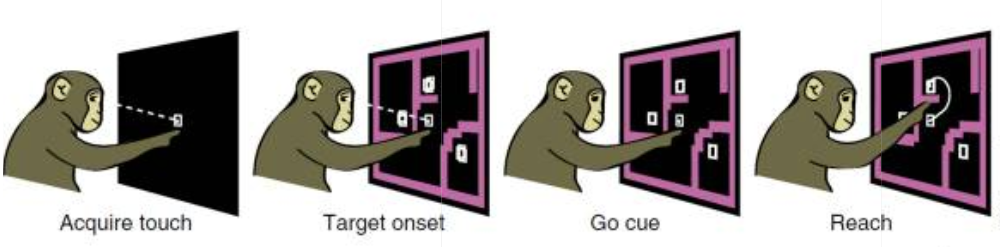

In [1]:
from IPython.display import display, Image
display(Image(filename="img/maze.png", embed=True))

### 1.1 Task

The maze task is a delayed center-out reaching task, meaning that there was a period between target presentation and the go cue when the monkey could plan and prepare its movement. The reaches took place in a number of maze configurations, resulting in a variety of straight and curved reaches. In some trials, three targets were presented, though only one was reachable, further complicating the task for the monkey. The delayed reaching paradigm allows for the examination of neural activity during both movement preparation and execution.

### 1.2 Data

For these datasets, neural activity was recorded from two Utah arrays: one implanted in the dorsal premotor cortex, which is thought to play a role in movement planning, and one in the primary motor cortex. This recorded data was spike sorted offline into the provided unit spike times. In addition to the neural data, cursor position and the monkeys' hand and gaze position were recorded during the experiment, and we estimated the hand velocity offline using the recorded hand position.

The MC_Maze datasets are entirely trialized, and no data was recorded between trials. As a result, though the data is presented here as a single continuous block, trials are separated by NaN margins to indicate when the data is discontinuous. In addition, in three of our dataset files, we reduced the number of trials to a fixed amount for evaluation of model performance on limited data.

## 2 Exploring the data

### 2.1 Setup

First, let's make the necessary imports and load the dataset.

In [2]:
## Download dataset and required packages if necessary
# !pip install git+https://github.com/neurallatents/nlb_tools.git
# !pip install dandi
# !dandi download https://gui.dandiarchive.org/#/dandiset/000128

In [3]:
## Imports

# %matplotlib widget # uncomment for interactive plots
from nlb_tools.nwb_interface import NWBDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
## Load dataset
dataset = NWBDataset("../../../000140/sub-Jenkins", "*train", split_heldout=False)
# dataset = NWBDataset("000128/sub-Jenkins/", "*train", split_heldout=False)

### 2.2 Continuous data

The continuous data provided with the MC_Maze datasets includes:
* `cursor_pos` - x and y position of the cursor controlled by the monkey
* `eye_pos` - x and y position of the monkey's point of gaze on the screen, in mm
* `hand_pos` - x and y position of the monkey's hand, in mm
* `hand_vel` - x and y velocities of the monkey's hand, in mm/s, computed offline using `np.gradient`
* `spikes` - spike times binned at 1 ms

In [5]:
## View 'dataset.data'
dataset.data

/Users/Emily/miniconda3/envs/filtered-point-process/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


signal_type            cursor_pos           eye_pos       hand_pos             \
channel                         x         y       x    y         x          y   
clock_time                                                                      
0 days 00:00:00         -4.100000  3.000000   -11.9 -5.6 -4.069391 -31.888893   
0 days 00:00:00.001000  -4.073506  3.007478   -10.1 -5.9 -4.066941 -31.900723   
0 days 00:00:00.002000  -4.048922  3.012831   -10.2 -4.1 -4.064521 -31.912980   
0 days 00:00:00.003000  -4.027829  3.014146   -10.0 -5.6 -4.062168 -31.925501   
0 days 00:00:00.004000  -4.011346  3.010063   -10.5 -8.8 -4.059822 -31.938112   
...                           ...       ...     ...  ...       ...        ...   
0 days 00:04:50.795000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 00:04:50.796000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 00:04:50.797000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 00:04:50.798000        NaN       NaN     NaN  NaN       NaN        NaN   
0 days 00:04:50.799000        NaN       NaN     NaN  NaN       NaN        NaN   

signal_type             hand_vel            spikes       ...                 \
channel                        x          y   1011 1012  ... 2791 2792 2801   
clock_time                                               ...                  
0 days 00:00:00         2.450720 -11.829852    0.0  0.0  ...  0.0  0.0  0.0   
0 days 00:00:00.001000  2.435183 -12.043778    0.0  0.0  ...  0.0  0.0  0.0   
0 days 00:00:00.002000  2.386269 -12.389198    0.0  0.0  ...  0.0  0.0  0.0   
0 days 00:00:00.003000  2.349501 -12.565892    0.0  0.0  ...  0.0  0.0  0.0   
0 days 00:00:00.004000  2.333177 -12.663237    0.0  0.0  ...  0.0  0.0  0.0   
...                          ...        ...    ...  ...  ...  ...  ...  ...   
0 days 00:04:50.795000       NaN        NaN    NaN  NaN  ...  NaN  NaN  NaN   
0 days 00:04:50.796000       NaN        NaN    NaN  NaN  ...  NaN  NaN  NaN   
0 days 00:04:50.797000       NaN        NaN    NaN  NaN  ...  NaN  NaN  NaN   
0 days 00:04:50.798000       NaN        NaN    NaN  NaN  ...  NaN  NaN  NaN   
0 days 00:04:50.799000       NaN        NaN    NaN  NaN  ...  NaN  NaN  NaN   

signal_type                                                
channel                2802 2812 2821 2841 2842 2861 2951  
clock_time                                                 
0 days 00:00:00         0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.001000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.002000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.003000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
0 days 00:00:00.004000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
...                     ...  ...  ...  ...  ...  ...  ...  
0 days 00:04:50.795000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 00:04:50.796000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 00:04:50.797000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 00:04:50.798000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
0 days 00:04:50.799000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[293666 rows x 150 columns]

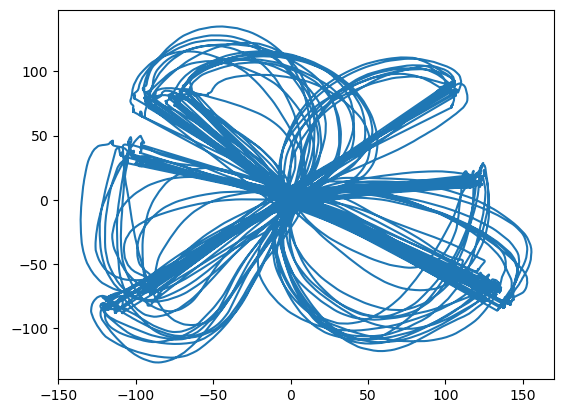

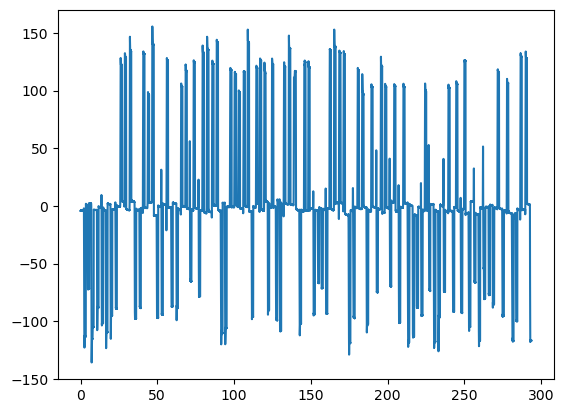

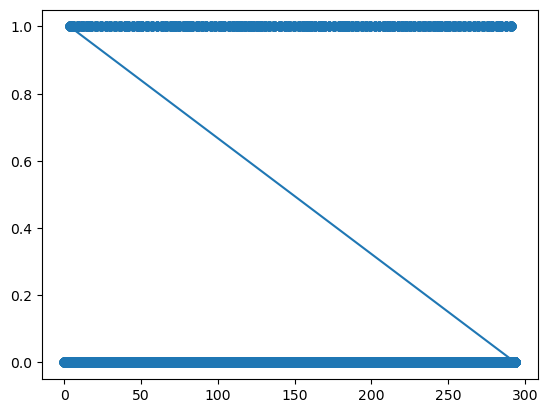

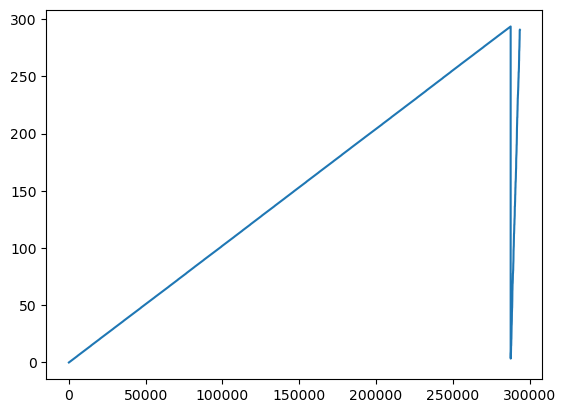

In [6]:
plt.figure()
plt.plot(dataset.data['cursor_pos']['x'], dataset.data['cursor_pos']['y'])

plt.figure()
plt.plot(dataset.data.index.total_seconds(), dataset.data['cursor_pos']['x'], label='x position')

# print(dataset.data.index[-1].total_seconds())  # total recording time in seconds

# Plot isnan as a function of time (the index)
plt.figure()
plt.plot(dataset.data.index.total_seconds(), np.isnan(dataset.data['cursor_pos']['x']), 'o-', label='isnan x position')

# Plot the index as a function of row number
plt.figure()
plt.plot(np.arange(len(dataset.data.index)), dataset.data.index.total_seconds(), label='time (s)')

# # Remove the rows after time goes back to zero
# time_zero_idx = np.where(dataset.data.index.total_seconds() == 3.421)
# data = dataset.data.iloc[:time_zero_idx[0][0], :]

# data

In [7]:
ta = dataset.data.index.total_seconds()
spikes = dataset.data.spikes.to_numpy().astype(np.float32)
cursor_pos = dataset.data['cursor_pos'].to_numpy()
hand_pos = dataset.data['hand_pos'].to_numpy()
hand_vel = dataset.data['hand_vel'].to_numpy()

# Lag Cursor Position by 80ms relative to spikes
cursor_pos = cursor_pos[80:,:]
hand_pos = hand_pos[80:,:]
hand_vel = hand_vel[80:,:]
spikes = spikes[:-80,:]
ta = ta[:-80]

print(cursor_pos.shape)
print(hand_pos.shape)
print(hand_vel.shape)
print(spikes.shape)


(293586, 2)
(293586, 2)
(293586, 2)
(293586, 142)


In [8]:
# Estimate spiking data by smothing with a  20 ms sd Gaussian kernel
from scipy.ndimage import gaussian_filter1d
firing_rate = gaussian_filter1d(spikes, sigma=20, axis=0)*1000  # convert to firing rate in Hz

# Remove rows with NaN values in cursor_pos
valid_rows = ~np.isnan(cursor_pos).any(axis=1)
ta = ta[valid_rows]
firing_rate = firing_rate[valid_rows, :]
cursor_pos = cursor_pos[valid_rows, :]
hand_pos = hand_pos[valid_rows, :]
hand_vel = hand_vel[valid_rows, :]

Text(0, 0.5, 'Smoothed Spike Rate + offset')

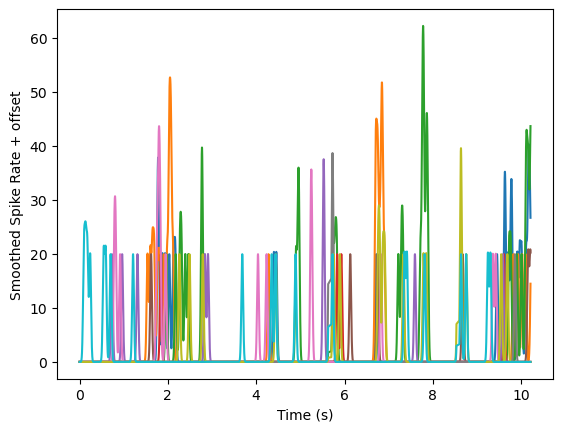

In [9]:

# plot smoothed spikes for first 10 neurons
plt.figure()
for i in range(10):
    plt.plot(ta[:10000], firing_rate[:10000, i] , label=f'Neuron {i}')
plt.xlabel('Time (s)')
plt.ylabel('Smoothed Spike Rate + offset')

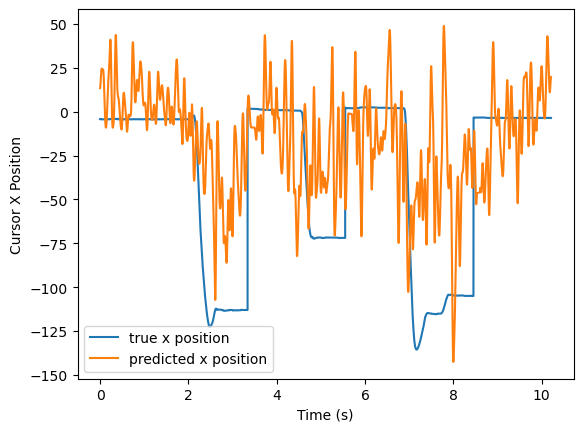

In [10]:
# Regress cursor position from firing rate
reg = Ridge(alpha=0.0)  
reg.fit(firing_rate, cursor_pos)
pred_cursor_pos = reg.predict(firing_rate)    
# Plot true vs predicted cursor position
plt.figure()
plt.plot(ta[:10000], cursor_pos[:10000, 0], label='true x position')
plt.plot(ta[:10000], pred_cursor_pos[:10000, 0], label='predicted x position')
plt.xlabel('Time (s)')
plt.ylabel('Cursor X Position')
plt.legend()

In [11]:
# print r^2
for pred in [cursor_pos, hand_pos, hand_vel]:
    reg = Ridge(alpha=0.0)  
    reg.fit(firing_rate, pred)
    r2 = reg.score(firing_rate, pred)
    print(f'R^2: {r2:.4f}')

R^2: 0.3973
R^2: 0.3984
R^2: 0.2780


Text(0, 0.5, 'Cursor Y Position')

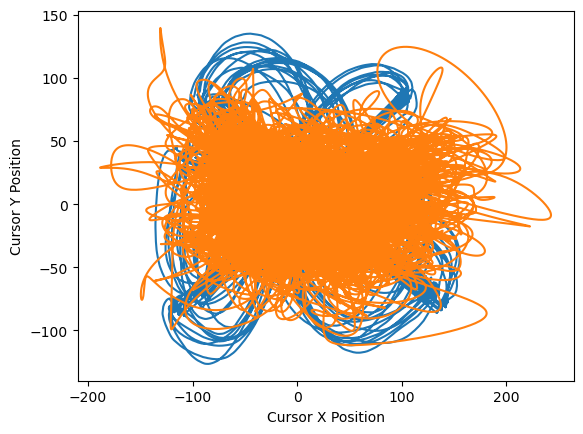

In [12]:
# Plot x and y cursor positions and predicted
plt.figure()
plt.plot(cursor_pos[:, 0],cursor_pos[:, 1], label='true')
plt.plot(pred_cursor_pos[:, 0],pred_cursor_pos[:, 1], label='predicted')
plt.xlabel('Cursor X Position')
plt.ylabel('Cursor Y Position')

Text(0.5, 1.0, 'True vs Predicted Cursor X Position')

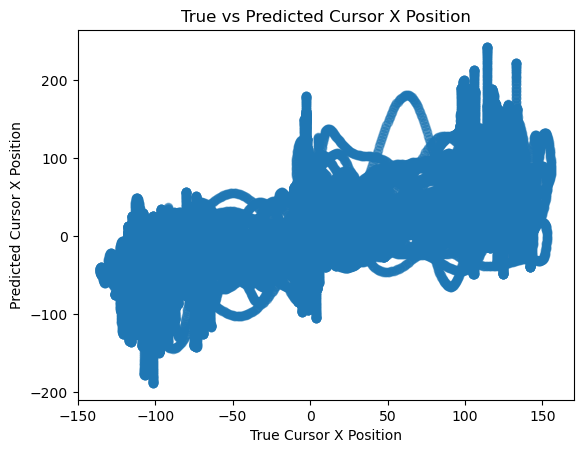

In [13]:
# Scatter plot of true vs predicted cursor position
plt.figure()
plt.scatter(cursor_pos[:, 0], pred_cursor_pos[:, 0], alpha=0.5)
plt.xlabel('True Cursor X Position')
plt.ylabel('Predicted Cursor X Position')
plt.title('True vs Predicted Cursor X Position')

In [20]:
# Save the spiking and cursor position data as a single csv file
df_firing_rate = pd.DataFrame(firing_rate, columns=[f'neuron_fr_{i}' for i in range(firing_rate.shape[1])])
df_spikes = pd.DataFrame(spikes, columns=[f'neuron_spikes_{i}' for i in range(spikes.shape[1])])
df_cursor_pos = pd.DataFrame(cursor_pos, columns=['cursor_x', 'cursor_y'])
df_hand_pos = pd.DataFrame(hand_pos, columns=['hand_x', 'hand_y'])
df_hand_vel = pd.DataFrame(hand_vel, columns=['hand_vx', 'hand_vy'])

# combine into single dataframe with time axis
df = pd.concat([pd.Series(ta, name='time'), df_firing_rate, df_spikes, df_cursor_pos, df_hand_pos, df_hand_vel], axis=1)

# save the first 60 seconds only to reduce file size
df = df[df['time'] <= 60.0]
df.to_csv('mc_maze_simplified.csv', index=False)